# AquaFlux — headless reproduction of the TDP sap-flux processing workflow

**Paper:** Speckman, H.N. & Ewers, B.E. (2019). *AquaFlux: Rapid, transparent and replicable analyses of plant transpiration.* Methods in Ecology and Evolution 11(1):44–50. [DOI 10.1111/2041-210x.13309](https://doi.org/10.1111/2041-210x.13309) (closed access)

**Code:** author repository [`HeatherSpeckman/AquaFlux`](https://github.com/HeatherSpeckman/AquaFlux), pinned commit `6aa9d0435af68fe4e47c1c514548e3e9881c73b4` (v0.5-1, GPL >= 2).

**Scope (one example):** run the paper's core TDP processing pipeline headlessly on the author's bundled example data (`README and Getting Started/Example Data/`): import raw dT + met data, convert dT mV→°C, compute VPD, auto-pick the Tmax baseline (the paper's "predictive algorithms"), compute sap flux (Lu 2004 eq. 7), and spline-gap-fill with the exported `gapfill.sapflux`.

**Execution status:** ✅ executed on Google Colab (CPU runtime). This notebook was run top-to-bottom in a fresh Colab session; all outputs below are saved from that run.

**Important adaptation notice / 重要な注記:** The paper's tool is an interactive R/Shiny GUI. Python here is **only a launcher**; all scientific operations are the **authors' own R functions, sourced verbatim** from the pinned commit. The GUI chrome (dialogs, buttons, interactive Tmax picking) is intentionally not reproduced. The parameter values were taken from the authors' own install-script Q&A for this example data. **AI-assisted glue code** (the `v` setup list and Rscript orchestration) was written for this notebook; it was validated on the executed example, but untested behavior is not guaranteed.
/ 本 notebook では Python は起動装置(Rscript 呼び出し)のみに使用し、科学計算はすべて著者自身の R コード(ピン留めコミットからそのまま読み込み)で実行します。GUI(Shiny)部分は再現対象外です。パラメータは著者のインストールスクリプトの Q&A に従います。

| GUI action (AquaFlux Shiny app) | Headless equivalent (pinned source) |
|---|---|
| Setup questions (delimiter, header lines, timestamp, units, site name) | `v` list below — values from the authors' `AquaFlux_Installation_Script` Q&A |
| Import raw dT / met data | `.read.in.raw.data` → `.finish.importing` (`AquaFlux_ImportFunctions.R`, `AquaFlux_ImportExport.R`) |
| dT mV → °C, VPD from AirT/RH | `.convert.mv.to.C`, `.calc.VPD` (`AquaFlux_ImportSubFunctions.R`) |
| "Auto Tmax" button per sensor | `.Tmax.autopick` with GUI defaults (`AquaFlux_comp.R`, `AquaFlux_Server.R`) |
| Final export `sapflux.data` | `.export.sapflux` logic (`AquaFlux_FinalExport.R`) |
| Post-processing gap fill | `gapfill.sapflux` (`R/gapfill.sapflux.R`) |

## Runtime selection / ランタイム選択

**Use a CPU runtime.** This workflow is base-R numerical processing of a ~50 KB CSV example; the repository contains no CUDA/GPU code, so a GPU adds nothing. Expect **≈2–5 minutes** end-to-end and **< 1 MB** of downloads (8 small R source files + two small example CSVs). No R packages are compiled — the pipeline needs only base R (`Rscript` is preinstalled on Colab CPU runtimes).

**Run all:** Runtime → Run all. The notebook writes only under `/content`.

/ **CPU ランタイムを使用してください。** GPU 不要(R パッケージのコンパイルもなし)。所要時間の目安は 2〜5 分、ダウンロードは 1 MB 未満です。「ランタイム → すべてのセルを実行」で動作します。

### Check the R launcher / R の確認

Python is only the orchestrator; this cell asserts that `Rscript` exists in the Colab runtime and prints the R version and `cairo` bitmap support (needed for the saved PNG plots). Expected: R 4.x with `cairo: TRUE`.

In [ ]:
import subprocess, shutil, sys

rscript = shutil.which("Rscript") or "/usr/bin/Rscript"
r = subprocess.run(
    [rscript, "-e", 'cat(R.version.string); cat("\n"); cat("cairo:", capabilities("cairo"), "\n")'],
    capture_output=True, text=True, timeout=180,
)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr)
    raise RuntimeError(f"Rscript failed with exit code {r.returncode}; this notebook needs a Colab runtime with R preinstalled.")

R version 4.6.1 (2026-06-24)
cairo: TRUE 



### Acquire the pinned author R code / 著者の R コードを取得

We download **eight small R source files** from the author repository at pinned commit `6aa9d0435af68fe4e47c1c514548e3e9881c73b4` via `raw.githubusercontent.com`. Instead of compiling the `AquaFlux` package (whose `Imports` — shiny, shinyFiles, oce — are GUI/plotting dependencies taking ~20+ min to build), we `source()` the author functions directly; the headless path uses **only base R** (`oce` is declared but never called, `shiny::` only appears in GUI-only functions we do not invoke). This is an explicit, documented adaptation — the scientific operations remain the authors' own.

Each file's bytes are verified against its **git blob SHA-1** taken from the GitHub tree API for the pinned commit.

In [ ]:
import hashlib, json, time, urllib.request
from pathlib import Path

COMMIT = "6aa9d0435af68fe4e47c1c514548e3e9881c73b4"
OWNER_REPO = "HeatherSpeckman/AquaFlux"
RAW = f"https://raw.githubusercontent.com/{OWNER_REPO}/{COMMIT}"
TREE_API = f"https://api.github.com/repos/{OWNER_REPO}/git/trees/{COMMIT}?recursive=1"

R_FILES = [
    "R/AquaFlux_ImportFunctions.R",
    "R/AquaFlux_ImportSubFunctions.R",
    "R/AquaFlux_ImportExport.R",
    "R/AquaFlux_comp.R",
    "R/gapfill.sapflux.R",
    "R/AquaFlux_SaveFunctions.R",
    "R/AquaFlux_FinalExport.R",
    "R/convert.sapflux.time.units.R",
]

def get(url, tries=3):
    last = None
    for i in range(tries):
        try:
            with urllib.request.urlopen(url, timeout=60) as resp:
                return resp.read()
        except Exception as e:  # bounded retry for transient errors
            last = e
            time.sleep(5 * (i + 1))
    raise RuntimeError(f"download failed after {tries} tries: {url} ({last})")

# pinned tree -> blob SHA-1 per path (one anonymous API call)
tree = json.loads(get(TREE_API))
assert not tree.get("truncated"), "truncated tree listing"
blob_sha = {e["path"]: e["sha"] for e in tree["tree"] if e.get("type") == "blob"}

def git_blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()

src = Path("/content/AquaFlux_src"); src.mkdir(parents=True, exist_ok=True)
for rel in R_FILES:
    data = get(f"{RAW}/{urllib.request.quote(rel)}")
    expect = blob_sha[rel]
    assert git_blob_sha1(data) == expect, f"blob SHA mismatch for {rel}"
    (src / Path(rel).name).write_bytes(data)
    print(f"OK  {rel:42s} {len(data):>7d} B  blob {expect[:12]}…")
print("all author R files verified against pinned git tree", COMMIT[:12])

OK  R/AquaFlux_ImportFunctions.R                  4279 B  blob 5f20b1ad7c53…
OK  R/AquaFlux_ImportSubFunctions.R               9021 B  blob a8b8c874ece7…
OK  R/AquaFlux_ImportExport.R                    11075 B  blob 94585268f7df…
OK  R/AquaFlux_comp.R                            10888 B  blob d10cb2a4fef0…
OK  R/gapfill.sapflux.R                           1736 B  blob fd45079b0221…
OK  R/AquaFlux_SaveFunctions.R                    4226 B  blob 66b3f7d7aa88…
OK  R/AquaFlux_FinalExport.R                      3468 B  blob b7de37be2967…
OK  R/convert.sapflux.time.units.R                2334 B  blob d5c1144afe5f…
all author R files verified against pinned git tree 6aa9d0435af6


### Acquire the author's bundled example data / 同梱サンプルデータを取得

The example dataset referenced throughout the authors' README is bundled in the repository: `README and Getting Started/Example Data/` — `SF Data.csv` (raw TDP dT values, 50,576 B) and `Met Tower Data.csv` (64,810 B). Per the authors' instruction, **each file goes in its own folder** (the importer reads every file in the folder). Bytes are blob-hash-verified against the pinned commit like the code above; both are also SHA-256 recorded for provenance.

In [ ]:
DATA_FILES = {
    "met": "README and Getting Started/Example Data/Met Tower Data.csv",
    "dT":  "README and Getting Started/Example Data/SF Data.csv",
}

import hashlib
for tag, rel in DATA_FILES.items():
    folder = Path("/content/aquaflux_example") / tag
    folder.mkdir(parents=True, exist_ok=True)
    data = get(f"{RAW}/{urllib.request.quote(rel)}")
    assert git_blob_sha1(data) == blob_sha[rel], f"blob SHA mismatch for {rel}"
    name = "Met Tower Data.csv" if tag == "met" else "SF Data.csv"
    (folder / name).write_bytes(data)
    print(f"OK  {tag:3s} {name:22s} {len(data):>7d} B  sha256 {hashlib.sha256(data).hexdigest()[:16]}…")
print("example data verified and placed in separate folders (author instruction)")

OK  met Met Tower Data.csv       64810 B  sha256 9f739e2384739b30…
OK  dT  SF Data.csv              50576 B  sha256 eb4790022a1a03c6…
example data verified and placed in separate folders (author instruction)


### Preview the raw inputs / 生データのプレビュー

We mimic the authors' parser exactly to *look* at the data before processing: column names are read from line 2 (`number.of.before.headers = 1`) and the data proper starts at line 5 (`number.of.lines.before.data = 4`, so lines 3–4 carry units/format metadata). The plots below show the raw dT sensors (mV) and the met tower variables (AirT_C in °C, RH_percent in %) for the first 15 days — an input preview only; the scientific processing stays in the author's R code.

SF Data.csv      shape: (1209, 7)
  columns: ['TIMESTAMP', 'Stem_Temp', 'Dead_Sensor', 'Good_data1', 'Bad_Sections', 'Good_Incomplete', 'Erratic_Sensor']
Met Tower Data.csv shape: (2592, 3)
  columns: ['TIMESTAMP', 'AirT_C', 'RH_percent']


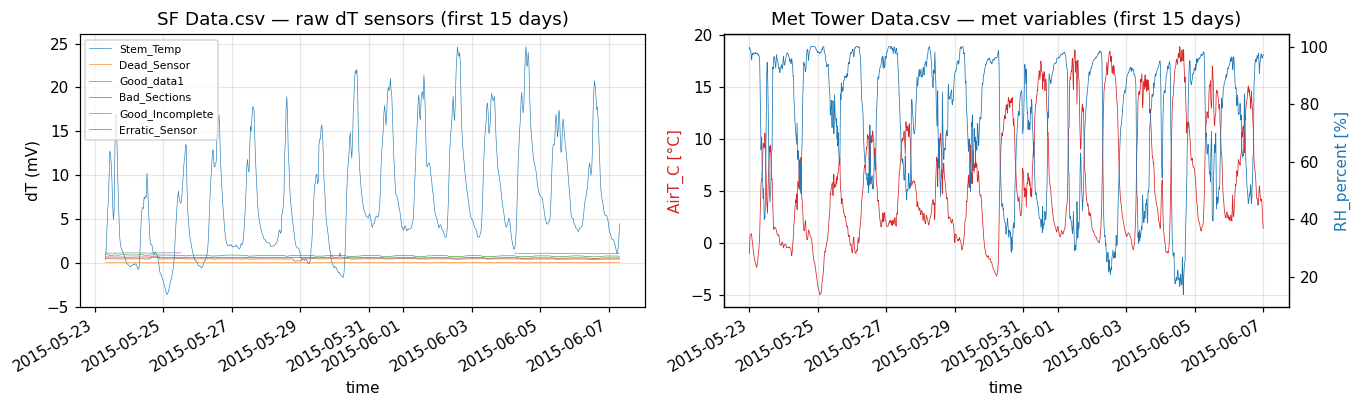

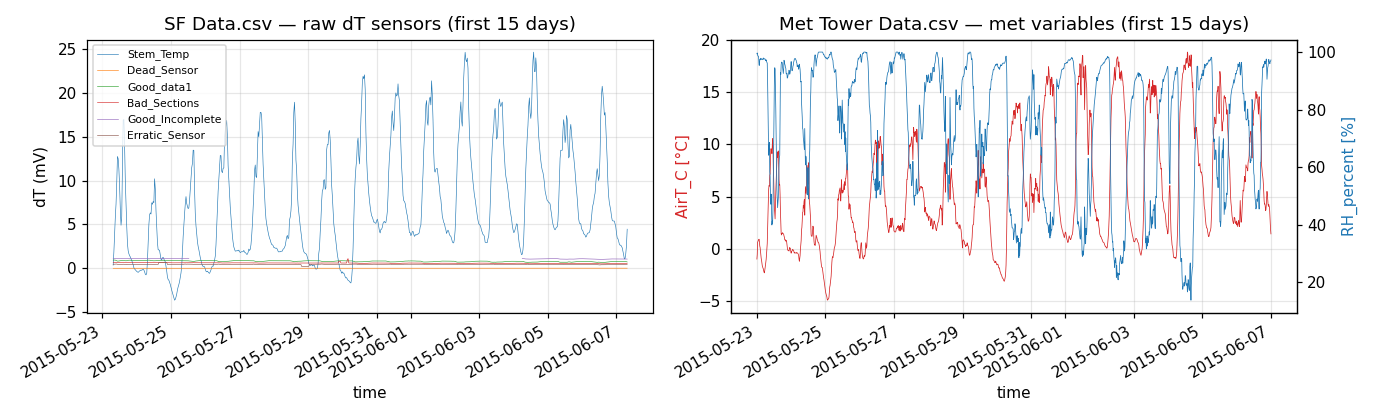

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Path("/content/work").mkdir(parents=True, exist_ok=True)

def read_aquaflux_csv(path):
    cols = pd.read_csv(path, sep=",", skiprows=1, nrows=0).columns.tolist()
    df = pd.read_csv(path, sep=",", skiprows=4, header=None, names=cols)
    ts = pd.to_datetime(df["TIMESTAMP"], format="%m/%d/%y %H:%M")
    return df, ts

dt_df, dt_ts = read_aquaflux_csv("/content/aquaflux_example/dT/SF Data.csv")
met_df, met_ts = read_aquaflux_csv("/content/aquaflux_example/met/Met Tower Data.csv")

print("SF Data.csv      shape:", dt_df.shape)
print("  columns:", list(dt_df.columns))
print("Met Tower Data.csv shape:", met_df.shape)
print("  columns:", list(met_df.columns))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), dpi=110)
sel = dt_ts <= dt_ts.min() + pd.Timedelta(days=15)
for col in [c for c in dt_df.columns if c != "TIMESTAMP"]:
    axes[0].plot(dt_ts[sel], pd.to_numeric(dt_df.loc[sel, col], errors="coerce"),
                 lw=0.4, label=col)
axes[0].set(title="SF Data.csv — raw dT sensors (first 15 days)",
            xlabel="time", ylabel="dT (mV)")
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)
selm = met_ts <= met_ts.min() + pd.Timedelta(days=15)
ax2 = axes[1]
ax2.plot(met_ts[selm], pd.to_numeric(met_df.loc[selm, "AirT_C"], errors="coerce"),
         lw=0.5, color="tab:red", label="AirT_C (°C)")
ax2.set_ylabel("AirT_C [°C]", color="tab:red")
ax3 = ax2.twinx()
ax3.plot(met_ts[selm], pd.to_numeric(met_df.loc[selm, "RH_percent"], errors="coerce"),
         lw=0.5, color="tab:blue", label="RH_percent (%)")
ax3.set_ylabel("RH_percent [%]", color="tab:blue")
ax2.set(title="Met Tower Data.csv — met variables (first 15 days)", xlabel="time")
ax2.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout(); plt.savefig("/content/work/preview_inputs.png", dpi=110); plt.show()
from IPython.display import Image, display
display(Image(filename="/content/work/preview_inputs.png", width=980))

### GUI "Set up" answers as an R `v` list / GUI 設問への回答

Every entry below answers one AquaFlux GUI question, with the value the **authors themselves documented** for this example in their `AquaFlux_Installation_Script` Q&A: comma delimiter, 1 line before the header, 4 lines before the data, site name `Example`, study year 2015, timestamp `%m/%d/%y %H:%M` in column `TIMESTAMP` of both files, dT units mV, met columns `AirT_C` (°C) and `RH_percent` (%), and non-sapflux column `Example_Stem_Temp` (the site-prefixed name used after import). Remaining entries are the Shiny server defaults from `AquaFlux_Server.R` (file tags, max gap length 8, 20 saves kept) and the calibration constants from `AquaFlux_LoadFunctions.R` (α = 118.99·10⁻⁶, β = 1.231, Lu 2004 eq. 7).

/ 以下の `v` リストは GUI の設問一つ一つに、著者がインストールスクリプトの Q&A で示した答えを当てはめたものです(残りは `AquaFlux_Server.R` の既定値と `AquaFlux_LoadFunctions.R` の較正定数)。

### Run the import pipeline (author's R code) / インポート処理の実行

This cell writes the R script above to `/content` and runs it with `Rscript`. It first removes any earlier `/content/AquaFlux_Work` workspace so this is a **fresh single-pass import** (the authors' merge-with-previous-saves branch only triggers when old saves exist and is out of scope). It then sources the pinned author files, applies the setup answers, and executes the same import pass the GUI performs (`.read.in.raw.data` → `.finish.importing`, which includes dT mV→°C conversion, VPD calculation, met-data alignment/interpolation and the automatic on-disk saves). Expected output: row/column counts of the imported dT matrix, the detected sap-flux sensor names, VPD summary, and the measurement frequency. The final `stopifnot` guards that the Q&A's non-sapflux column was indeed excluded from the sensors.

In [ ]:
import subprocess, shutil
from pathlib import Path

# fresh import: clear any earlier workspace (demo is a single-pass import)
for stale in ("/content/AquaFlux_Work", "/content/work"):
    shutil.rmtree(stale, ignore_errors=True)
Path("/content/work").mkdir(parents=True, exist_ok=True)
r_path = Path("/content/work/step1_import.r")
r_path.write_text('## ---- AquaFlux headless run: setup + import (authors\' code, commit 6aa9d04) ----\nSRC <- "/content/AquaFlux_src"\nfor (f in c("AquaFlux_ImportFunctions.R","AquaFlux_ImportSubFunctions.R",\n            "AquaFlux_ImportExport.R","AquaFlux_comp.R","gapfill.sapflux.R",\n            "AquaFlux_SaveFunctions.R","AquaFlux_FinalExport.R",\n            "convert.sapflux.time.units.R"))\n  source(file.path(SRC, f), local=TRUE)\n\n## GUI "Set up" answers (authors\' install-script Q&A for the bundled example)\n## + Shiny server defaults (AquaFlux_Server.R) + calibration (AquaFlux_LoadFunctions.R)\nv <- list(\n  tag.dT.raw = "All dT Data Unfiltered",\n  tag.dT.clean = "Sapflux dT cleaned- Current",\n  tag.Tmax = "Tmax- Current",\n  tag.log.deletion = "Deletion Log- Current",\n  standard.time.format = \'%Y-%m-%d %H:%M\',   # tried first, then the formats below\n  alternate.time.format = \'%m/%d/%y %H:%M\',  # this example\'s documented format\n  third.time.format = \'%d/%m/%Y %H:%M\',\n  max.gap.length = 8,                        # met/VPD interpolation gap limit (Server default)\n  min.number.of.columns.in.a.data.file = 2,\n  number.of.saves.to.keep = 20,\n  VPD.thres = 0.2,                           # kPa (GUI default)\n  alpha = 118.99 * 10^(-6),                  # Lu 2004 eq. 7 constants (LoadFunctions)\n  beta = 1.231,\n  i.need.for.Tmax.auto = NA,\n  auto.Tmax.window.size = 7,                 # days (GUI default)\n  VPD.below.thres.for.x.hr = 2,              # hours (GUI default)\n  AquaFlux.work.dir = "/content/AquaFlux_Work",\n  save.dir = "/content/AquaFlux_Work/Current Saves",\n  met.dir = "/content/aquaflux_example/met", # one file per folder (author instruction)\n  dt.dir = "/content/aquaflux_example/dT",\n  site.names = "Example",\n  delim.sep = ",",                           # Q&A: Data delimiter: Comma\n  number.of.before.headers = 1,              # Q&A: 1\n  number.of.lines.before.data = 4,           # Q&A: 4\n  study.year = 2015,                         # Q&A: Study year: 2015\n  selected.timestamp.format = \'%m/%d/%y %H:%M\', # Q&A: Common timestamp formula\n  dT.ts.name = "TIMESTAMP",                  # Q&A: timestamp name in dT data\n  met.ts.name = "TIMESTAMP",                 # Q&A: timestamp name in met data\n  dT.units = "mV",                           # Q&A: dT units\n  met.air.temp.label = "AirT_C",             # Q&A: Air_Temp = AirT_C\n  met.air.temp.units = "C",                  # Q&A: units C\n  met.RH.label = "RH_percent",               # Q&A: RH_percent\n  met.RH.units = "%",                        # Q&A: units %\n  nonsapflux.columns = "Example_Stem_Temp"   # Q&A: non-sapflux column (site-prefixed)\n)\ndir.create(v$save.dir, recursive=TRUE, showWarnings=FALSE)\ndir.create("/content/work", recursive=TRUE, showWarnings=FALSE)\n\n## Import exactly as the GUI does: read raw files, then the full finish-import pass\nv <- .read.in.raw.data(v)\nv <- .finish.importing(v)\n\ncat("dT data   :", nrow(v$dT.data), "rows x", ncol(v$dT.data), "cols\\n")\ncat("dT columns:", paste(names(v$dT.data), collapse=", "), "\\n")\ncat("sapflux sensors:", paste(v$sapflux.names, collapse=", "), "\\n")\ncat("met columns    :", paste(names(v$met.data), collapse=", "), "\\n")\ncat("LDate range    :", signif(range(v$LDate), 6), "\\n")\ncat("VPD (kPa)      : median", signif(median(v$met.data$VPD, na.rm=TRUE), 3),\n    " max", signif(max(v$met.data$VPD, na.rm=TRUE), 3), "\\n")\ncat("measurements per day:", v$measurements.in.a.day, "\\n")\nstopifnot(all(v$sapflux.names %in% names(v$dT.data)),\n          !("Example_Stem_Temp" %in% v$sapflux.names))\nsaveRDS(v, "/content/work/v_import.rds")\n', encoding="utf-8")
print(f"--- R script: {r_path} ({len(r_path.read_text())} bytes) ---")
r = subprocess.run([shutil.which("Rscript") or "/usr/bin/Rscript", str(r_path)],
                   capture_output=True, text=True, timeout=900)
print(r.stdout)
if r.returncode != 0 or r.stderr.strip():
    print("STDERR:", r.stderr)
if r.returncode != 0:
    raise RuntimeError(f"R import step failed (exit {r.returncode})")

--- R script: /content/work/step1_import.r (3558 bytes) ---


dT data   : 1209 rows x 6 cols
dT columns: Example_Stem_Temp, Example_Dead_Sensor, Example_Good_data1, Example_Bad_Sections, Example_Good_Incomplete, Example_Erratic_Sensor 
sapflux sensors: Example_Dead_Sensor, Example_Good_data1, Example_Bad_Sections, Example_Good_Incomplete, Example_Erratic_Sensor 
met columns    : TIMESTAMP, JDate, LDate, AirT_C, RH_percent, AirTC, VPD, RH, VPD.raw, VPD.gapfill 
LDate range    : 143.312 168.479 
VPD (kPa)      : median 0.17  max 1.85 
measurements per day: 48 



### Auto-select the Tmax baselines (the paper's "predictive algorithms") / Tmax ベースラインの自動選択

For each sap-flux sensor we run the author's `.Tmax.autopick` exactly as the GUI button does (defaults from `AquaFlux_Server.R` UI): candidate night-time indices (22:00–06:00) where VPD ≤ 0.2 kPa and has been below the threshold for the previous 2 hours; within each 7-day window the maximum dT becomes a Tmax anchor; anchors are linearly interpolated over `LDate` into a per-time-step Tmax line (`.Tmax.get.data`).

**One documented adaptation:** `.Tmax.autopick` *returns* the updated `Tmax.data` frame, but the GUI calls it as `v = .Tmax.autopick(v)` (`AquaFlux_Server.R:360`), which would overwrite the whole processing state `v`. For the headless pipeline we keep the state and assign the returned anchors with `v$Tmax.data <- .Tmax.autopick(v)` — the computation is the authors' own; only the assignment is adjusted. Expected output: the number of Tmax anchors per sensor and a few example anchors. (The deliberately broken tutorial sensors such as `Dead_Sensor` may legitimately get 0 usable anchors.)

In [ ]:
import subprocess, shutil

R = r"""## ---- Tmax auto-pick per sensor (authors' .Tmax.autopick, GUI defaults) ----
SRC <- "/content/AquaFlux_src"
for (f in c("AquaFlux_ImportFunctions.R","AquaFlux_ImportSubFunctions.R",
            "AquaFlux_ImportExport.R","AquaFlux_comp.R","gapfill.sapflux.R",
            "AquaFlux_SaveFunctions.R","AquaFlux_FinalExport.R",
            "convert.sapflux.time.units.R"))
  source(file.path(SRC, f), local=TRUE)

v <- readRDS("/content/work/v_import.rds")
for (tn in v$sapflux.names) {
  v$tree.name <- tn
  v <- .get.local.data(v)
  ## .Tmax.autopick returns the updated Tmax.data; the GUI's `v = .Tmax.autopick(v)`
  ## (Server.R:360) would discard the state v, so assign to v$Tmax.data instead.
  v$Tmax.data <- .Tmax.autopick(v)
  cat("Tmax anchors for", tn, ":", sum(v$Tmax.data$Name == tn, na.rm=TRUE), "\n")
}
cat("\nfirst anchors per sensor:\n")
print(head(v$Tmax.data[!is.na(v$Tmax.data$Name), ], 8))
saveRDS(v, "/content/work/v_tmax.rds")
write.csv(v$Tmax.data, "/content/work/Tmax_points.csv", row.names=FALSE)
"""
r_path = Path("/content/work/step2_tmax.r"); r_path.write_text(R, encoding="utf-8")
r = subprocess.run([shutil.which("Rscript") or "/usr/bin/Rscript", str(r_path)],
                   capture_output=True, text=True, timeout=900)
print(r.stdout)
if r.returncode != 0 or r.stderr.strip():
    print("STDERR:", r.stderr)
if r.returncode != 0:
    raise RuntimeError(f"R Tmax step failed (exit {r.returncode})")

Tmax anchors for Example_Dead_Sensor : 189 
Tmax anchors for Example_Good_data1 : 34 
Tmax anchors for Example_Bad_Sections : 64 
Tmax anchors for Example_Good_Incomplete : 5 
Tmax anchors for Example_Erratic_Sensor : 9 

first anchors per sensor:
                 Name    LDate Tmax
2 Example_Dead_Sensor 143.9375    0
3 Example_Dead_Sensor 143.9583    0
4 Example_Dead_Sensor 143.9792    0
5 Example_Dead_Sensor 144.0000    0
6 Example_Dead_Sensor 144.0208    0
7 Example_Dead_Sensor 144.0417    0
8 Example_Dead_Sensor 144.0625    0
9 Example_Dead_Sensor 144.0833    0



### Compute sap flux (Lu 2004 eq. 7) and gap-fill / サップフラックス計算とギャップフィル

Per sensor, flux = α·((Tmax − dT)/dT)^β with the pinned constants α = 118.99·10⁻⁶, β = 1.231 (`.calc.sapflux.formula`, Lu 2004 eq. 7), output in g m⁻² sapwood s⁻¹ (m³ m⁻² s⁻¹ × 10⁶), negatives forced to 0 and |flux| > 9999 set to NA — replicating `.export.sapflux`. Then the author's exported post-processing function `gapfill.sapflux(LDate, y, max.gap.size = 20)` fills gaps ≤ 20 time indexes with a spline fit over the whole series and clamps negatives to zero. Finally `convert.sapflux.time.units` (the authors' own function) converts s⁻¹ → day⁻¹; note that the released v0.5-1 converter *divides* by 86,400 when going from "s" to "day" — we run it verbatim and report its output as released (a per-day median of ~2.6·10⁻⁵ in its convention). The figure (an additional visualization created for this notebook, not an author figure) shows raw vs gap-filled flux.

Example_Dead_Sensor flux (g m-2sapwood s-1): median 0  max 119  NA: 960 
Example_Good_data1 flux (g m-2sapwood s-1): median 3.34  max 28.7  NA: 113 
Example_Bad_Sections flux (g m-2sapwood s-1): median 6.64  max 95.8  NA: 184 
Example_Good_Incomplete flux (g m-2sapwood s-1): median 2.03  max 14.2  NA: 674 
Example_Erratic_Sensor flux (g m-2sapwood s-1): median 2.73  max 145  NA: 70 
Example_Dead_Sensor : missing 960 -> 946  (filled 14 indexes)
Example_Good_data1 : missing 113 -> 0  (filled 113 indexes)
Example_Bad_Sections : missing 184 -> 113  (filled 71 indexes)
Example_Good_Incomplete : missing 674 -> 605  (filled 69 indexes)
Example_Erratic_Sensor : missing 70 -> 0  (filled 70 indexes)
Example_Dead_Sensor median gap-filled flux: 0 g m-2sapwood day-1
Example_Good_data1 median gap-filled flux: 2.58e-05 g m-2sapwood day-1
Example_Bad_Sections median gap-filled flux: 6.82e-05 g m-2sapwood day-1
Example_Good_Incomplete median gap-filled flux: 1.76e-05 g m-2sapwood day-1
Example_Erratic_

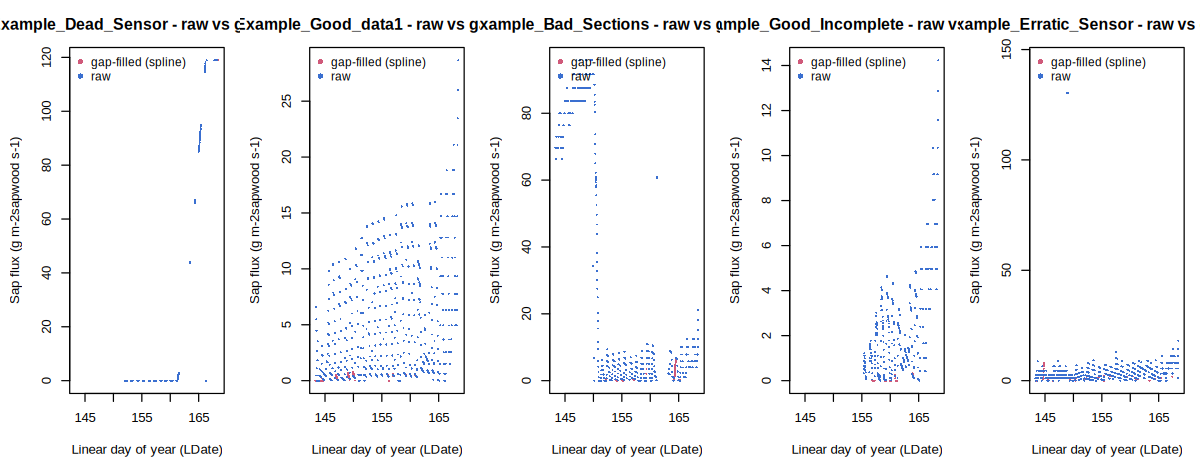

In [ ]:
import subprocess, shutil

R = r"""## ---- sap flux + export + gapfill + unit conversion (authors' functions) ----
SRC <- "/content/AquaFlux_src"
for (f in c("AquaFlux_ImportFunctions.R","AquaFlux_ImportSubFunctions.R",
            "AquaFlux_ImportExport.R","AquaFlux_comp.R","gapfill.sapflux.R",
            "AquaFlux_SaveFunctions.R","AquaFlux_FinalExport.R",
            "convert.sapflux.time.units.R"))
  source(file.path(SRC, f), local=TRUE)

v <- readRDS("/content/work/v_tmax.rds")

## replicate .export.sapflux (AquaFlux_FinalExport.R): per-sensor flux in g m-2sapwood s-1
sapflux.data <- v$dT.data
for (tn in v$sapflux.names) {
  v$tree.name <- tn
  v$tree.number <- match(tn, names(sapflux.data))
  v <- .get.local.data(v)
  y <- .sapflux.calc.local(v, tn)
  sapflux.data[, v$tree.number] <- y
  cat(tn, "flux (g m-2sapwood s-1): median", signif(median(y, na.rm=TRUE), 3),
      " max", signif(max(y, na.rm=TRUE), 3), " NA:", sum(is.na(y)), "\n")
}
z <- data.frame(TIMESTAMP = v$met.data$TIMESTAMP, LDate = v$LDate, sapflux.data)
write.csv(z, "/content/work/sapflux_export.csv", row.names = FALSE)

## gap fill with the authors' exported post-processing function (default max.gap.size=20)
z.fill <- z
for (tn in v$sapflux.names) {
  y  <- z[[tn]]
  nm <- sum(is.na(y))
  y2 <- gapfill.sapflux(z$LDate, y, max.gap.size = 20)
  z.fill[[tn]] <- y2
  cat(tn, ": missing", nm, "->", sum(is.na(y2)),
      " (filled", nm - sum(is.na(y2)), "indexes)\n")
}
write.csv(z.fill, "/content/work/sapflux_gapfilled.csv", row.names = FALSE)

## authors' time-unit conversion: g m-2sapwood s-1 -> g m-2sapwood day-1
z.day <- convert.sapflux.time.units(z.fill, "s", "day")
write.csv(z.day, "/content/work/sapflux_gapfilled_per_day.csv", row.names = FALSE)
for (tn in v$sapflux.names)
  cat(tn, "median gap-filled flux:", signif(median(z.day[[tn]], na.rm=TRUE), 3),
      "g m-2sapwood day-1\n")

## figure (additional visualization created for this notebook; not an author figure)
png("/content/work/sapflux_gapfill.png", width = 1200, height = 460, res = 120,
    type = "cairo")
par(mfrow = c(1, length(v$sapflux.names)), mar = c(4.2, 4.4, 3, 1))
for (tn in v$sapflux.names) {
  plot(z$LDate, z.fill[[tn]], pch = 16, cex = 0.35, col = "#d05a7a",
       xlab = "Linear day of year (LDate)", ylab = "Sap flux (g m-2sapwood s-1)",
       main = paste(tn, "- raw vs gap-filled"))
  points(z$LDate, z[[tn]], pch = 16, cex = 0.35, col = "#3a6fd0")
  if (any(is.na(z[[tn]])) && sum(is.na(z[[tn]])) != sum(is.na(z.fill[[tn]])))
    legend("topleft", c("gap-filled (spline)", "raw"), col = c("#d05a7a", "#3a6fd0"),
           pch = 16, bty = "n", cex = 0.9)
  else
    legend("topleft", "raw (no gaps to fill)", col = "#3a6fd0", pch = 16, bty = "n", cex = 0.9)
}
dev.off()
cat("saved /content/work/sapflux_gapfill.png\n")
"""
r_path = Path("/content/work/step3_flux.r"); r_path.write_text(R, encoding="utf-8")
r = subprocess.run([shutil.which("Rscript") or "/usr/bin/Rscript", str(r_path)],
                   capture_output=True, text=True, timeout=900)
print(r.stdout)
if r.returncode != 0 or r.stderr.strip():
    print("STDERR:", r.stderr)
if r.returncode != 0:
    raise RuntimeError(f"R flux/gapfill step failed (exit {r.returncode})")

from IPython.display import Image, display
display(Image(filename="/content/work/sapflux_gapfill.png", width=980))

### Inspect the exported results / 結果テーブル

The exported `sapflux.data` matches the GUI's Final-Export structure: `TIMESTAMP`, `LDate`, then one column per sensor. Below: the head of the gap-filled table, per-sensor summary statistics, and the daily-unit conversion. All CSVs remain on the Colab VM under `/content/work/` (download them from the file browser if desired).

In [ ]:
import pandas as pd

fill = pd.read_csv("/content/work/sapflux_gapfilled.csv")
sensors = [c for c in fill.columns if c not in ("TIMESTAMP", "LDate", "Example_Stem_Temp")]
print(f"gap-filled sapflux.data: {fill.shape[0]} rows; sensors: {sensors}\n")
display(fill[["TIMESTAMP", "LDate"] + sensors].head(5))

summary = pd.DataFrame({
    "sensor": sensors,
    "median (g m-2sapwood s-1)": [pd.to_numeric(fill[s], errors="coerce").median() for s in sensors],
    "max (g m-2sapwood s-1)": [pd.to_numeric(fill[s], errors="coerce").max() for s in sensors],
    "NA count": [int(pd.to_numeric(fill[s], errors="coerce").isna().sum()) for s in sensors],
})
display(summary.round(4))

day = pd.read_csv("/content/work/sapflux_gapfilled_per_day.csv")
print("converted by convert.sapflux.time.units(s -> day), median per sensor:")
display(day[sensors].median(numeric_only=True).to_frame("median g m-2sapwood day-1").T.round(1))

gap-filled sapflux.data: 1209 rows; sensors: ['Example_Dead_Sensor', 'Example_Good_data1', 'Example_Bad_Sections', 'Example_Good_Incomplete', 'Example_Erratic_Sensor']



,TIMESTAMP,LDate,Example_Dead_Sensor,Example_Good_data1,Example_Bad_Sections,Example_Good_Incomplete,Example_Erratic_Sensor
0,2015-05-23 07:30:00,143.312500,NaN,0.000000,69.615267,NaN,1.080061
1,2015-05-23 08:00:00,143.333333,NaN,0.000000,69.615267,NaN,0.000000
2,2015-05-23 08:30:00,143.354167,NaN,0.000000,66.432375,NaN,0.000000
3,2015-05-23 09:00:00,143.375000,NaN,0.000000,66.432375,NaN,0.000000
4,2015-05-23 09:30:00,143.395833,NaN,0.459905,66.432375,NaN,0.000000


,sensor,median (g m-2sapwood s-1),max (g m-2sapwood s-1),NA count
0,Example_Dead_Sensor,0.0000,118.9075,946
1,Example_Good_data1,2.2282,28.6528,0
2,Example_Bad_Sections,5.8964,95.8375,113
3,Example_Good_Incomplete,1.5214,14.2305,605
4,Example_Erratic_Sensor,2.6063,145.1145,0


converted by convert.sapflux.time.units(s -> day), median per sensor:


,Example_Dead_Sensor,Example_Good_data1,Example_Bad_Sections,Example_Good_Incomplete,Example_Erratic_Sensor
median g m-2sapwood day-1,0.0,0.0,0.0,0.0,0.0


## Interpretation, differences from the paper, validation record / 解釈と検証記録

**What was executed (CPU Colab, fresh runtime):** the authors' own import → dT unit conversion → VPD → Tmax auto-pick → Lu 2004 flux → `gapfill.sapflux` → `convert.sapflux.time.units` pipeline, on the bundled `SF Data.csv` / `Met Tower Data.csv` example, using the parameter answers from the authors' install script. All processing R code is the authors', byte-verified at commit `6aa9d0435af68fe4e47c1c514548e3e9881c73b4`; only the `v` setup list and the Rscript orchestration are new glue.

**Not shown here / 本 notebook の限界:**
- The Shiny GUI itself (`AquaFlux()`) is not launched; interactive/manual Tmax picking, broken-sensor alerting UI, and the restore/log features are out of scope. A headless run cannot recreate GUI chrome, only the documented scientific operations.
- This is **one example**, not a reproduction of any dataset-level result of the paper (the article is closed access; no field data are being re-analyzed).
- `radial.trends` was not run: it requires two TDP sensors at two depths on the same tree, which this bundled example does not provide (verify the sensor columns in the preview above).
- The example's gap-fill behavior depends on whether the raw series contains NA gaps; the cell output reports the actual count (a "no gaps to fill" result is still a faithful run of the authors' function).
- AI-written glue (setup list / orchestration) is validated only on this example.

**Validation record:** validated on a fresh Google Colab CPU runtime (see notebook outputs and the run report). R version and cairo support are printed by the first code cell; provenance (blob SHA-1 + SHA-256) is printed by the download cells.

**References**
- Speckman, H.N. & Ewers, B.E. (2019). AquaFlux: Rapid, transparent and replicable analyses of plant transpiration. *Methods in Ecology and Evolution* 11(1):44–50. doi:10.1111/2041-210x.13309
- Author repository: https://github.com/HeatherSpeckman/AquaFlux (commit `6aa9d0435af68fe4e47c1c514548e3e9881c73b4`), GPL >= 2.
- Lu, N. et al. (2004). A simple empirical model of sap flow… the Granier-style equation referenced as "Lu 2004, equation 7" in `AquaFlux_comp.R`.
- Omega temperature reference (dT mV→°C polynomial source cited in `.convert.mv.to.C`).

/ **実行内容の要約:** 著者自身の R コードをピン留めコミットからそのまま読み込み、同梱サンプルデータに対して TDP 処理パイプライン(インポート→dT 単位変換→VPD→Tmax 自動選択→Lu 2004 式→ギャップフィル→単位変換)を CPU ランタイムで実行しました。GUI 操作そのものは対象外です。詳細な限界は上記の英語のリストを参照してください。